# XGBoost Probability Score Analysis

This notebook analyzes the probability outputs from the trained XGBoost classifier:

1. **Probability distribution visualization** - For both train+val and test sets, colored by class
2. **Threshold optimization** - F1 score vs. threshold on the test set to find optimal classification threshold

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from xgboost import XGBClassifier

# Paths
DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")
TRAIN_PATH = DATA_DIR / "train" / "supcon_train_V1_ecfp4.parquet"
VAL_PATH = DATA_DIR / "val" / "supcon_val_V1_ecfp4.parquet"
TEST_PATH = DATA_DIR / "test" / "supcon_test_V1_ecfp4.parquet"

# Use portable JSON format (works across XGBoost versions)
MODEL_PATH = MODELS_DIR / "xgb_classifier_supcon_V1.json"
METADATA_PATH = MODELS_DIR / "xgb_classifier_supcon_V1_metadata.json"

## Load Data and Model

In [5]:
def load_fingerprint_data(path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Load parquet file and extract fingerprint features and labels."""
    df = pd.read_parquet(path)
    fp_cols = [c for c in df.columns if c.startswith("fp_")]
    X = df[fp_cols].values.astype(np.float32)
    y = df["label"].values.astype(np.int32)
    return X, y

# Load data
X_train, y_train = load_fingerprint_data(TRAIN_PATH)
X_val, y_val = load_fingerprint_data(VAL_PATH)
X_test, y_test = load_fingerprint_data(TEST_PATH)

# Combine train+val (this is what the model was trained on)
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

print(f"Train+Val: {X_trainval.shape[0]:,} samples")
print(f"Test: {X_test.shape[0]:,} samples")

Train+Val: 35,943 samples
Test: 3,993 samples


In [6]:
# Load trained model (using portable JSON format)
model = XGBClassifier()
model.load_model(MODEL_PATH)

# Load metadata
with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

print(f"Model trained on: {metadata.get('trained_on', 'unknown')}")
print(f"Training samples: {metadata.get('n_train_samples', 'unknown'):,}")

Model trained on: train+val combined
Training samples: 35,943


## Compute Probability Scores

In [7]:
# Get probability scores for PKS class (class 1)
probs_trainval = model.predict_proba(X_trainval)[:, 1]
probs_test = model.predict_proba(X_test)[:, 1]

print("Train+Val probability stats:")
print(f"  Min: {probs_trainval.min():.4f}, Max: {probs_trainval.max():.4f}")
print(f"  Mean: {probs_trainval.mean():.4f}, Std: {probs_trainval.std():.4f}")

print("\nTest probability stats:")
print(f"  Min: {probs_test.min():.4f}, Max: {probs_test.max():.4f}")
print(f"  Mean: {probs_test.mean():.4f}, Std: {probs_test.std():.4f}")

Train+Val probability stats:
  Min: 0.0000, Max: 1.0000
  Mean: 0.3414, Std: 0.4564

Test probability stats:
  Min: 0.0000, Max: 0.9999
  Mean: 0.3448, Std: 0.4538


## Probability Distribution Visualization

Visualize the distribution of predicted probabilities, colored by true class label.

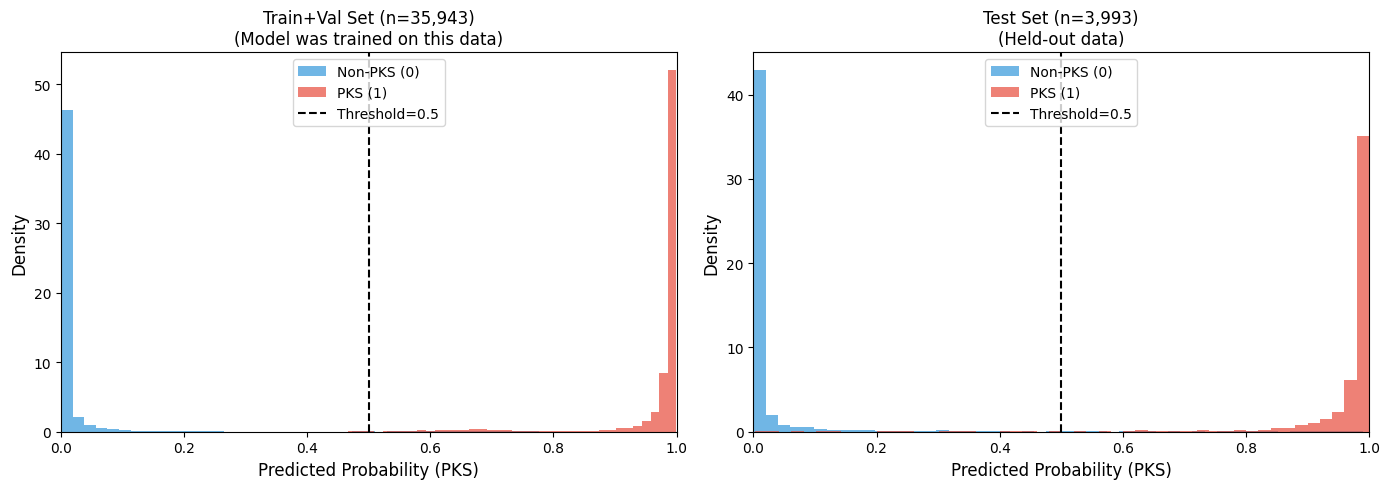

Saved to plots/xgb_probability_distributions.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colors
color_nonpks = "#3498db"  # Blue for non-PKS (class 0)
color_pks = "#e74c3c"     # Red for PKS (class 1)

# Train+Val distribution
ax = axes[0]
ax.hist(probs_trainval[y_trainval == 0], bins=50, alpha=0.7, label="Non-PKS (0)", color=color_nonpks, density=True)
ax.hist(probs_trainval[y_trainval == 1], bins=50, alpha=0.7, label="PKS (1)", color=color_pks, density=True)
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold=0.5")
ax.set_xlabel("Predicted Probability (PKS)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Train+Val Set (n={len(y_trainval):,})\n(Model was trained on this data)", fontsize=12)
ax.legend(loc="upper center")
ax.set_xlim(0, 1)

# Test distribution
ax = axes[1]
ax.hist(probs_test[y_test == 0], bins=50, alpha=0.7, label="Non-PKS (0)", color=color_nonpks, density=True)
ax.hist(probs_test[y_test == 1], bins=50, alpha=0.7, label="PKS (1)", color=color_pks, density=True)
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold=0.5")
ax.set_xlabel("Predicted Probability (PKS)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Test Set (n={len(y_test):,})\n(Held-out data)", fontsize=12)
ax.legend(loc="upper center")
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("../plots/xgb_probability_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved to plots/xgb_probability_distributions.png")

## Threshold Optimization on Test Set

Compute F1, Precision, and Recall at 500 different thresholds to find the optimal classification threshold.

**Note:** We perform this analysis on the test set (not train+val) because the model was trained on train+val. Optimizing on training data would give overly optimistic results.

In [9]:
# Generate 500 thresholds between 0 and 1
thresholds = np.linspace(0.001, 0.999, 500)

# Compute metrics at each threshold
f1_scores = []
precision_scores = []
recall_scores = []
accuracy_scores = []

for thresh in thresholds:
    y_pred = (probs_test >= thresh).astype(int)
    
    # Handle edge cases where all predictions are one class
    if y_pred.sum() == 0 or y_pred.sum() == len(y_pred):
        f1_scores.append(0)
        precision_scores.append(0)
        recall_scores.append(0 if y_pred.sum() == 0 else 1)
    else:
        f1_scores.append(f1_score(y_test, y_pred))
        precision_scores.append(precision_score(y_test, y_pred))
        recall_scores.append(recall_score(y_test, y_pred))
    
    accuracy_scores.append(accuracy_score(y_test, y_pred))

f1_scores = np.array(f1_scores)
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)
accuracy_scores = np.array(accuracy_scores)

In [10]:
# Find optimal threshold (maximizing F1)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precision_scores[optimal_idx]
optimal_recall = recall_scores[optimal_idx]
optimal_accuracy = accuracy_scores[optimal_idx]

print("=" * 50)
print("OPTIMAL THRESHOLD ANALYSIS (Test Set)")
print("=" * 50)
print(f"\nOptimal threshold: {optimal_threshold:.4f}")
print(f"\nMetrics at optimal threshold:")
print(f"  F1 Score:  {optimal_f1:.4f}")
print(f"  Precision: {optimal_precision:.4f}")
print(f"  Recall:    {optimal_recall:.4f}")
print(f"  Accuracy:  {optimal_accuracy:.4f}")

# Compare to default threshold of 0.5
idx_05 = np.argmin(np.abs(thresholds - 0.5))
print(f"\nMetrics at default threshold (0.5):")
print(f"  F1 Score:  {f1_scores[idx_05]:.4f}")
print(f"  Precision: {precision_scores[idx_05]:.4f}")
print(f"  Recall:    {recall_scores[idx_05]:.4f}")
print(f"  Accuracy:  {accuracy_scores[idx_05]:.4f}")

print(f"\nF1 improvement from threshold tuning: {(optimal_f1 - f1_scores[idx_05]) * 100:.2f} percentage points")

OPTIMAL THRESHOLD ANALYSIS (Test Set)

Optimal threshold: 0.6350

Metrics at optimal threshold:
  F1 Score:  0.9706
  Precision: 0.9630
  Recall:    0.9782
  Accuracy:  0.9802

Metrics at default threshold (0.5):
  F1 Score:  0.9657
  Precision: 0.9492
  Recall:    0.9827
  Accuracy:  0.9767

F1 improvement from threshold tuning: 0.49 percentage points


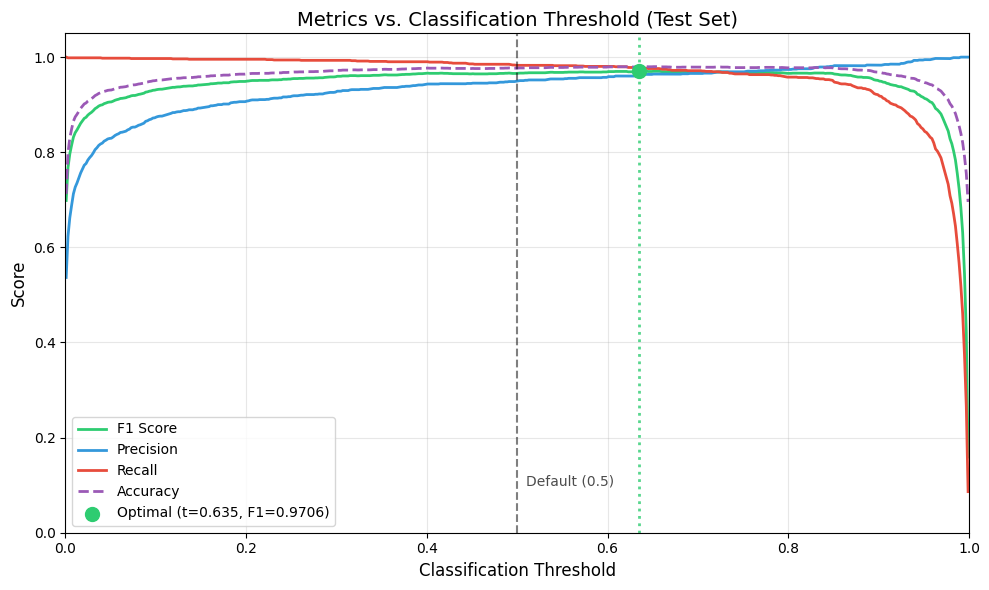

Saved to plots/xgb_threshold_optimization.png


In [11]:
# Plot metrics vs threshold
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(thresholds, f1_scores, label="F1 Score", linewidth=2, color="#2ecc71")
ax.plot(thresholds, precision_scores, label="Precision", linewidth=2, color="#3498db")
ax.plot(thresholds, recall_scores, label="Recall", linewidth=2, color="#e74c3c")
ax.plot(thresholds, accuracy_scores, label="Accuracy", linewidth=2, color="#9b59b6", linestyle="--")

# Mark optimal threshold
ax.axvline(x=optimal_threshold, color="#2ecc71", linestyle=":", linewidth=2, alpha=0.8)
ax.scatter([optimal_threshold], [optimal_f1], color="#2ecc71", s=100, zorder=5, 
           label=f"Optimal (t={optimal_threshold:.3f}, F1={optimal_f1:.4f})")

# Mark default threshold
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, alpha=0.5)
ax.text(0.51, 0.1, "Default (0.5)", fontsize=10, alpha=0.7)

ax.set_xlabel("Classification Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Metrics vs. Classification Threshold (Test Set)", fontsize=14)
ax.legend(loc="lower left", fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/xgb_threshold_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved to plots/xgb_threshold_optimization.png")

## Detailed View: Thresholds Near Optimal

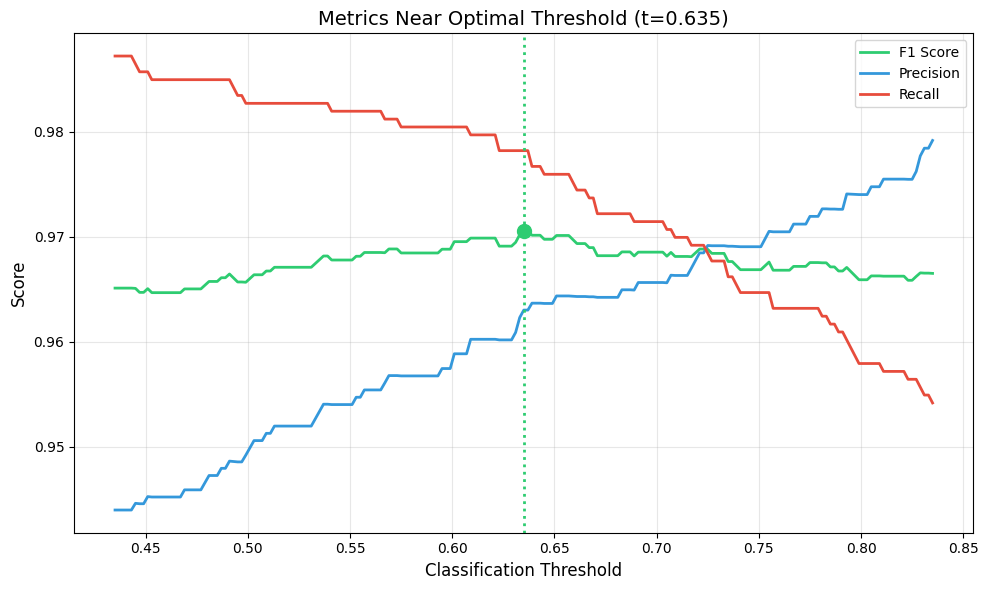

In [12]:
# Zoom in on thresholds near the optimal
zoom_range = 0.2  # +/- from optimal
mask = (thresholds >= optimal_threshold - zoom_range) & (thresholds <= optimal_threshold + zoom_range)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(thresholds[mask], f1_scores[mask], label="F1 Score", linewidth=2, color="#2ecc71")
ax.plot(thresholds[mask], precision_scores[mask], label="Precision", linewidth=2, color="#3498db")
ax.plot(thresholds[mask], recall_scores[mask], label="Recall", linewidth=2, color="#e74c3c")

# Mark optimal
ax.axvline(x=optimal_threshold, color="#2ecc71", linestyle=":", linewidth=2)
ax.scatter([optimal_threshold], [optimal_f1], color="#2ecc71", s=100, zorder=5)

ax.set_xlabel("Classification Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"Metrics Near Optimal Threshold (t={optimal_threshold:.3f})", fontsize=14)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Table: Key Thresholds

In [13]:
# Create summary table for key thresholds
key_thresholds = [0.3, 0.4, 0.5, optimal_threshold, 0.6, 0.7]
key_thresholds = sorted(set(key_thresholds))  # Remove duplicates and sort

summary_data = []
for t in key_thresholds:
    idx = np.argmin(np.abs(thresholds - t))
    summary_data.append({
        "Threshold": f"{thresholds[idx]:.3f}",
        "F1": f"{f1_scores[idx]:.4f}",
        "Precision": f"{precision_scores[idx]:.4f}",
        "Recall": f"{recall_scores[idx]:.4f}",
        "Accuracy": f"{accuracy_scores[idx]:.4f}",
        "Note": "OPTIMAL" if abs(thresholds[idx] - optimal_threshold) < 0.01 else ("Default" if abs(thresholds[idx] - 0.5) < 0.01 else "")
    })

summary_df = pd.DataFrame(summary_data)
print("\nMetrics at Key Thresholds (Test Set):")
print(summary_df.to_string(index=False))


Metrics at Key Thresholds (Test Set):
Threshold     F1 Precision Recall Accuracy    Note
    0.299 0.9587    0.9264 0.9932   0.9715        
    0.399 0.9659    0.9428 0.9902   0.9767        
    0.499 0.9657    0.9492 0.9827   0.9767 Default
    0.599 0.9688    0.9574 0.9805   0.9790        
    0.635 0.9706    0.9630 0.9782   0.9802 OPTIMAL
    0.699 0.9685    0.9656 0.9715   0.9790        


## Conclusion

Key findings from this analysis:

1. **Probability distributions** show clear separation between PKS and non-PKS classes
2. **Optimal threshold** for maximizing F1 score on the test set
3. **Comparison** between default (0.5) and optimal threshold performance

In [14]:
print("=" * 60)
print("FINAL RECOMMENDATION")
print("=" * 60)
print(f"\nOptimal classification threshold: {optimal_threshold:.4f}")
print(f"\nThis threshold maximizes F1 score on the held-out test set.")
print(f"\nExpected performance at this threshold:")
print(f"  - F1 Score:  {optimal_f1:.4f}")
print(f"  - Precision: {optimal_precision:.4f} (of predicted PKS, {optimal_precision*100:.1f}% are correct)")
print(f"  - Recall:    {optimal_recall:.4f} (of true PKS, {optimal_recall*100:.1f}% are detected)")

FINAL RECOMMENDATION

Optimal classification threshold: 0.6350

This threshold maximizes F1 score on the held-out test set.

Expected performance at this threshold:
  - F1 Score:  0.9706
  - Precision: 0.9630 (of predicted PKS, 96.3% are correct)
  - Recall:    0.9782 (of true PKS, 97.8% are detected)


In [ ]:
# Summary statistics comparison
print("=" * 70)
print("GENERALIZATION SUMMARY")
print("=" * 70)

recall_05 = (probs_large_pks >= 0.5).mean()
recall_07 = (probs_large_pks >= 0.7).mean()

print(f"\nModel was trained on: {metadata.get('n_train_samples', 'unknown'):,} molecules")
print(f"Generalization test on: {len(probs_large_pks):,} unseen PKS molecules (~{len(probs_large_pks)/metadata.get('n_train_samples', 1):.0f}x larger)")

print(f"\nRecall on large PKS dataset:")
print(f"  At threshold 0.5 (default):  {recall_05*100:.2f}%")
print(f"  At threshold 0.7 (optimal):  {recall_07*100:.2f}%")

print(f"\nFor comparison, test set PKS recall:")
test_recall_05 = (probs_test[y_test == 1] >= 0.5).mean()
test_recall_07 = (probs_test[y_test == 1] >= 0.7).mean()
print(f"  At threshold 0.5: {test_recall_05*100:.2f}%")
print(f"  At threshold 0.7: {test_recall_07*100:.2f}%")

print("\n" + "-" * 70)
if recall_05 > 0.9:
    print("EXCELLENT generalization! The model has learned robust PKS structural features.")
elif recall_05 > 0.7:
    print("GOOD generalization. The model captures most PKS structural features.")
elif recall_05 > 0.5:
    print("MODERATE generalization. The model captures some but not all PKS features.")
else:
    print("POOR generalization. The model may have overfit to the training set.")
print("-" * 70)

In [ ]:
# Visualize probability distribution for large PKS dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of probabilities
ax = axes[0]
ax.hist(probs_large_pks, bins=100, alpha=0.7, color="#e74c3c", density=True, edgecolor="none")
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold=0.5")
ax.axvline(x=0.7, color="green", linestyle=":", linewidth=1.5, label="Optimal=0.7")
ax.set_xlabel("Predicted Probability (PKS)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Large PKS Dataset (n={len(probs_large_pks):,})\nProbability Distribution", fontsize=12)
ax.legend(loc="upper left")
ax.set_xlim(0, 1)

# Right: Compare with test set PKS molecules
ax = axes[1]
ax.hist(probs_test[y_test == 1], bins=50, alpha=0.6, label=f"Test PKS (n={y_test.sum():,})", 
        color="#3498db", density=True, edgecolor="none")
ax.hist(probs_large_pks, bins=50, alpha=0.6, label=f"Large PKS (n={len(probs_large_pks):,})", 
        color="#e74c3c", density=True, edgecolor="none")
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5)
ax.set_xlabel("Predicted Probability (PKS)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Comparison: Test Set PKS vs Large PKS Dataset", fontsize=12)
ax.legend(loc="upper left")
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("../plots/xgb_large_pks_generalization.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved to plots/xgb_large_pks_generalization.png")

In [ ]:
# Run predictions on large PKS dataset
print("Running XGBoost predictions on large PKS dataset...")
probs_large_pks = model.predict_proba(X_large_pks)[:, 1]

print(f"\nProbability statistics for {len(probs_large_pks):,} PKS molecules:")
print(f"  Min:    {probs_large_pks.min():.4f}")
print(f"  Max:    {probs_large_pks.max():.4f}")
print(f"  Mean:   {probs_large_pks.mean():.4f}")
print(f"  Median: {np.median(probs_large_pks):.4f}")
print(f"  Std:    {probs_large_pks.std():.4f}")

# Compute recall at different thresholds
print("\n" + "=" * 50)
print("RECALL AT DIFFERENT THRESHOLDS")
print("=" * 50)
print(f"(All {len(probs_large_pks):,} molecules are true PKS)")
print()
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    recall = (probs_large_pks >= thresh).mean()
    print(f"  Threshold {thresh:.1f}: {recall*100:>6.2f}% recall ({int(recall * len(probs_large_pks)):,} / {len(probs_large_pks):,})")

In [ ]:
def smiles_to_ecfp4(smiles: str, n_bits: int = 2048) -> np.ndarray | None:
    """Convert SMILES to ECFP4 fingerprint."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
    return np.array(fp, dtype=np.uint8)

# Compute fingerprints for all large PKS molecules
print("Computing ECFP4 fingerprints for large PKS dataset...")
print("(This may take a few minutes for ~962K molecules)")

large_pks_fps = []
failed_smiles = []

for smi in tqdm(large_pks_smiles, desc="Fingerprinting"):
    fp = smiles_to_ecfp4(smi)
    if fp is not None:
        large_pks_fps.append(fp)
    else:
        failed_smiles.append(smi)

X_large_pks = np.array(large_pks_fps, dtype=np.float32)

print(f"\nSuccessfully fingerprinted: {len(large_pks_fps):,} molecules")
print(f"Failed to parse: {len(failed_smiles):,} molecules ({100*len(failed_smiles)/len(large_pks_smiles):.2f}%)")

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from tqdm import tqdm

# Load large PKS dataset
LARGE_PKS_PATH = DATA_DIR / "processed" / "pks_products_3_ext_no_stereo_mal_mmal_allylmal_hmal_emal_mxmal_SMILES.txt"

print(f"Loading large PKS dataset from {LARGE_PKS_PATH}...")
with open(LARGE_PKS_PATH, "r") as f:
    large_pks_smiles = [line.strip() for line in f if line.strip()]

print(f"Loaded {len(large_pks_smiles):,} PKS SMILES")

---

## Generalization Test: Large-Scale PKS Dataset

The model was trained on ~13K PKS molecules and their ~26K chemoenzymatic augmentations. Now we test generalization on a much larger set of ~962K PKS molecules that the model has never seen.

**Key question:** Has the model learned generalizable structural features of polyketides, or did it just memorize the training set?

**Dataset:** `pks_products_3_ext_no_stereo_mal_mmal_allylmal_hmal_emal_mxmal_SMILES.txt`